# Regression

Created on 2026-09-01

@author: Ruowen Xiao

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Local Regression Function
def local_regression(x_global, y_global, k, x_0):
    # choose k points nearest to x0
    index = np.argsort(np.abs(x_global - x_0))[:k]
    x = x_global[index]
    y = y_global[index]

    # weight
    h = np.max(np.abs(x - x_0))
    K = (1 - np.abs((x - x_0) / h)**3)**3

    # find beta_1 and beta_0
    x_w_mean = np.sum(K * x) / np.sum(K)
    y_w_mean = np.sum(K * y) / np.sum(K)
    beta_1 = np.sum(K * (x - x_w_mean) * (y - y_w_mean)) / np.sum(K * (x - x_w_mean)**2)
    beta_0 = y_w_mean - beta_1 * x_w_mean
    # print(f"x_0={x_0}, beta_0={beta_0:.2f}, beta_1={beta_1:.2f}")

    # calculate predicted value and standard deviation
    pred = beta_0 + beta_1 * x_0
    residual = y - beta_0 - beta_1 * x
    se = np.sqrt(np.sum(residual**2) / (k - 2))
    # print(f"x_0={x_0}, prediction={pred:.2f}, se={se:.2f} \n")
    return pred, se

In [3]:
# Cross Validation
# TODO
def cross_validate():
    return 30

In [4]:
# Load Data
data_path = "./data/pollution_cleaneddata.csv"
df = pd.read_csv(data_path, delimiter=',', dtype=float)
df = df.sort_values(by="POOR")

x = df["POOR"].to_numpy()  # observations of predictor
y = df["MORT"].to_numpy()  # observations of response
k = cross_validate()  # number of neighboring points
x_0_list = [10, 18, 25]  # values for prediction

In [5]:
# Calculation
results = [local_regression(x, y, k, x_0) for x_0 in x_0_list]

x_0=10, beta_0=728.99, beta_1=17.66
x_0=10, prediction=905.64, se=60.30 

x_0=18, beta_0=903.68, beta_1=2.89
x_0=18, prediction=955.62, se=59.05 

x_0=25, beta_0=795.26, beta_1=8.55
x_0=25, prediction=1008.92, se=61.55 



[ 9.4        10.29473684 11.18947368 12.08421053 12.97894737 13.87368421
 14.76842105 15.66315789 16.55789474 17.45263158 18.34736842 19.24210526
 20.13684211 21.03157895 21.92631579 22.82105263 23.71578947 24.61052632
 25.50526316 26.4       ]
[ 891.52029523  911.21569915  930.92635356  928.09494289  930.24246773
  944.46574209  942.58465853  950.83260754  951.76082421  954.7241139
  953.06656318  952.3340531   965.28342519  975.24730242  983.14861605
  990.45042031  997.75336611 1005.42705106 1013.56076153 1022.06761623]


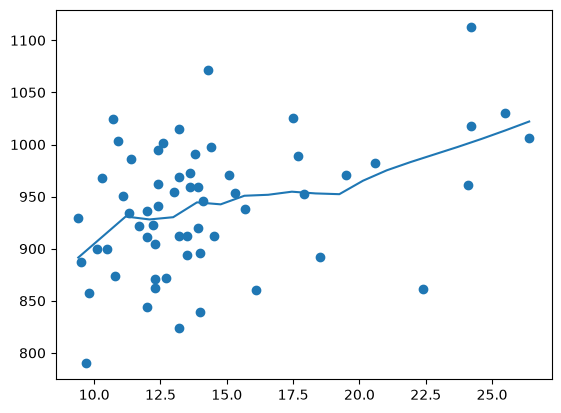

In [7]:
# Plot
x_0_grid = np.linspace(x.min(), x.max(), 20)
y_pred = np.array([local_regression(x, y, k, x_0)[0] for x_0 in x_0_grid])
print(x_0_grid)
print(y_pred)

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x_0_grid, y_pred)